# Partial Cross-Entropy Loss with SegFormer on LoveDA
### Weakly-Supervised Remote Sensing Segmentation via Point Annotations

**Assessment Tasks:**
1. Implement Partial Cross-Entropy Loss (with Focal variant)
2. Simulate sparse point labels from LoveDA masks → train SegFormer
3. Ablation experiments: (A) Point density, (B) CE vs Focal loss

**Dataset:** LoveDA — Urban/Rural land cover, 7 classes  
**Model:** SegFormer-B2 (HuggingFace `transformers`)  
**Framework:** PyTorch

---
**LoveDA Classes:**
```
0: Background  1: Building  2: Road  3: Water
4: Barren     5: Forest    6: Agriculture
```

## 0. Install Dependencies

In [ ]:
!pip install transformers accelerate timm albumentations matplotlib seaborn wandb -q
!pip install segmentation-models-pytorch -q  # fallback if HF slow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00


## 1. Imports & Config

In [ ]:
import os
import copy
import random
import numpy as np
import json
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from transformers import SegformerForSemanticSegmentation
from transformers import get_polynomial_decay_schedule_with_warmup

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
GPU: Tesla T4


In [ ]:
# ── Shared constants (defined before Config so CLASS_NAMES available everywhere)
CLASS_NAMES  = ['Background','Building','Road','Water','Barren','Forest','Agriculture']
CLASS_COLORS = np.array([
    [255, 255, 255],  # 0: Background
    [255,   0,   0],  # 1: Building
    [128, 128, 128],  # 2: Road
    [  0,   0, 255],  # 3: Water
    [210, 180, 140],  # 4: Barren
    [  0, 128,   0],  # 5: Forest
    [255, 255,   0],  # 6: Agriculture
], dtype=np.uint8)

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])


@dataclass
class Config:
    # ── Paths ──────────────────────────────────────────────────────────────
    # LoveDA Kaggle structure:
    # loveda-dataset/
    #   Train/Urban/images_png/  Train/Urban/masks_png/
    #   Train/Rural/images_png/  Train/Rural/masks_png/
    #   Val/Urban/...            Val/Rural/...
    data_root: str = '/kaggle/input/datasets/mohammedjaveed/loveda-dataset'
    output_dir: str = '/kaggle/working/outputs'

    # ── Dataset ────────────────────────────────────────────────────────────
    num_classes: int = 7
    ignore_index: int = 255          # unlabeled / void pixels
    image_size: int = 512
    domains: List[str] = field(default_factory=lambda: ['Urban', 'Rural'])

    # ── Point Annotation ───────────────────────────────────────────────────
    points_per_class: int = 5        # ablated in Exp A: {1, 3, 5, 10}

    # ── Model ──────────────────────────────────────────────────────────────
    model_name: str = 'nvidia/mit-b2'

    # ── Training ───────────────────────────────────────────────────────────
    epochs: int = 30
    batch_size: int = 4
    lr: float = 6e-5
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    grad_clip: float = 1.0
    num_workers: int = 2

    # ── Loss ───────────────────────────────────────────────────────────────
    loss_type: str = 'focal'         # ablated in Exp B: {'ce', 'focal'}
    focal_gamma: float = 2.0
    focal_alpha: float = 0.25

    # ── Logging ────────────────────────────────────────────────────────────
    log_every: int = 10
    eval_every: int = 1              # eval every N epochs

cfg = Config()
os.makedirs(cfg.output_dir, exist_ok=True)
print(json.dumps(cfg.__dict__, indent=2, default=str))


{
  "data_root": "/kaggle/input/datasets/mohammedjaveed/loveda-dataset",
  "output_dir": "/kaggle/working/outputs",
  "num_classes": 7,
  "ignore_index": 255,
  "image_size": 512,
  "domains": [
    "Urban",
    "Rural"
  ],
  "points_per_class": 5,
  "model_name": "nvidia/mit-b2",
  "epochs": 30,
  "batch_size": 4,
  "lr": 6e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "grad_clip": 1.0,
  "num_workers": 2,
  "loss_type": "focal",
  "focal_gamma": 2.0,
  "focal_alpha": 0.25,
  "log_every": 10,
  "eval_every": 1
}


## 2. Partial Cross-Entropy Loss

Formula from the assessment:
$$pfCE = \frac{\sum \text{FocalLoss}(pred, GT) \times \text{MASK}_{labeled}}{\sum \text{MASK}_{labeled}}$$

Key idea: compute CE/Focal loss element-wise, then **zero out unlabeled pixels** via the point mask, and normalize only over labeled pixels.

In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss for dense prediction (pixel-wise).
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma: float = 2.0, alpha: float = 0.25,
                 ignore_index: int = 255, reduction: str = 'none'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.ignore_index = ignore_index
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        logits:  [B, C, H, W]  raw (pre-softmax) network output
        targets: [B, H, W]     class indices; ignore_index for unlabeled
        returns: [B, H, W]     per-pixel focal loss (unreduced)
        """
        B, C, H, W = logits.shape

        # Build a safe target for CE computation (replace ignore with 0 temporarily)
        valid_mask = (targets != self.ignore_index)          # [B, H, W]
        safe_targets = targets.clone()
        safe_targets[~valid_mask] = 0

        # Standard CE loss element-wise (no reduction)
        log_probs = F.log_softmax(logits, dim=1)             # [B, C, H, W]
        ce_loss = F.nll_loss(
            log_probs, safe_targets,
            reduction='none', ignore_index=-1
        )                                                     # [B, H, W]

        # Probability of the true class: p_t
        probs = torch.exp(log_probs)                         # [B, C, H, W]
        # Gather p_t for the true class
        p_t = probs.gather(1, safe_targets.unsqueeze(1)).squeeze(1)  # [B, H, W]

        # Focal weight: (1 - p_t)^gamma
        focal_weight = (1.0 - p_t) ** self.gamma

        # Alpha weight (class-agnostic here; extend to per-class if needed)
        alpha_weight = torch.where(safe_targets > 0,
                                   torch.tensor(self.alpha, device=logits.device),
                                   torch.tensor(1 - self.alpha, device=logits.device))

        focal_loss = alpha_weight * focal_weight * ce_loss   # [B, H, W]

        # Zero out originally-ignored positions
        focal_loss = focal_loss * valid_mask.float()
        return focal_loss


class PartialCELoss(nn.Module):
    """
    Partial Cross-Entropy Loss for point-supervised segmentation.

    pfCE = Σ[ Loss(pred, GT) × MASK_labeled ] / Σ[ MASK_labeled ]

    MASK_labeled is the sparse binary point mask — 1 only at annotated pixels.
    Loss is either standard CE or Focal CE.
    """
    def __init__(self, loss_type: str = 'focal', gamma: float = 2.0,
                 alpha: float = 0.25, ignore_index: int = 255,
                 eps: float = 1e-6):
        super().__init__()
        assert loss_type in ('ce', 'focal'), f'Unknown loss_type: {loss_type}'
        self.loss_type = loss_type
        self.ignore_index = ignore_index
        self.eps = eps

        if loss_type == 'focal':
            self.base_loss_fn = FocalLoss(
                gamma=gamma, alpha=alpha,
                ignore_index=ignore_index, reduction='none'
            )
        else:
            # Wrap standard CE to return [B, H, W] unreduced
            self.base_loss_fn = None  # handled inline

    def forward(
        self,
        logits: torch.Tensor,      # [B, C, H, W]
        targets: torch.Tensor,     # [B, H, W]  full class labels (from mask)
        point_mask: torch.Tensor,  # [B, H, W]  binary: 1 = point annotated
    ) -> torch.Tensor:
        """
        Returns scalar loss averaged over labeled points only.
        """
        # --- Compute element-wise base loss ---
        if self.loss_type == 'focal':
            pixel_loss = self.base_loss_fn(logits, targets)  # [B, H, W]
        else:
            # Standard CE — use ignore_index to handle unlabeled pixels
            # But we additionally gate by point_mask below
            valid_mask = (targets != self.ignore_index)
            safe_targets = targets.clone()
            safe_targets[~valid_mask] = 0
            log_probs = F.log_softmax(logits, dim=1)
            pixel_loss = F.nll_loss(
                log_probs, safe_targets, reduction='none'
            ) * valid_mask.float()                           # [B, H, W]

        # --- Apply point mask (partial supervision gate) ---
        # point_mask: 1 only where we have a simulated point label
        point_mask = point_mask.float()
        masked_loss = pixel_loss * point_mask                # [B, H, W]

        # --- Normalize over labeled pixels only ---
        loss = masked_loss.sum() / (point_mask.sum() + self.eps)
        return loss


# ── Quick sanity check ────────────────────────────────────────────────────────
def test_loss():
    B, C, H, W = 2, 7, 64, 64
    logits  = torch.randn(B, C, H, W)
    targets = torch.randint(0, C, (B, H, W))

    # Sparse point mask — only ~1% of pixels labeled
    point_mask = torch.zeros(B, H, W)
    n_points = 20
    for b in range(B):
        ys = torch.randint(0, H, (n_points,))
        xs = torch.randint(0, W, (n_points,))
        point_mask[b, ys, xs] = 1.0

    for loss_type in ('ce', 'focal'):
        loss_fn = PartialCELoss(loss_type=loss_type)
        loss = loss_fn(logits, targets, point_mask)
        print(f'Partial {loss_type.upper()} loss: {loss.item():.4f}  '
              f'(labeled pixels: {int(point_mask.sum().item())} / {B*H*W})')

test_loss()

Partial CE loss: 2.2581  (labeled pixels: 40 / 8192)
Partial FOCAL loss: 0.5837  (labeled pixels: 40 / 8192)


## 3. Point Annotation Simulator

Given a full segmentation mask, sample `K` random points per class present in the image.
Returns a sparse `point_mask` and a sparse `point_label` map (ignore_index elsewhere).

In [ ]:
class PointAnnotationSimulator:
    """
    Converts a full dense mask into sparse point annotations.

    Strategy: For each class present in the image, sample exactly
    `points_per_class` random pixels belonging to that class.
    If a class has fewer pixels than requested, take all of them.

    Worker-safe: uses numpy random with per-call seed derived from
    image content so multiprocess DataLoader workers don't share state.
    """
    def __init__(self, points_per_class: int = 5, ignore_index: int = 255):
        self.points_per_class = points_per_class
        self.ignore_index = ignore_index
        # Do NOT store a single rng — create per simulate() call for worker safety

    def simulate(
        self,
        mask: np.ndarray,          # [H, W] dense label map
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Returns:
            point_label [H, W]: ignore_index everywhere except sampled points
            point_mask  [H, W]: binary float, 1 at sampled locations
        """
        H, W = mask.shape
        point_label = np.full((H, W), self.ignore_index, dtype=np.int64)
        point_mask  = np.zeros((H, W), dtype=np.float32)

        # Worker-safe: derive a seed from the mask content so results are
        # reproducible per image but independent across DataLoader workers
        rng = np.random.default_rng(int(mask.sum()) % (2**31))

        unique_classes = np.unique(mask)
        unique_classes = unique_classes[unique_classes != self.ignore_index]
        # Also exclude any stray negative values after remapping
        unique_classes = unique_classes[unique_classes >= 0]

        for cls in unique_classes:
            ys, xs = np.where(mask == cls)
            n_available = len(ys)
            if n_available == 0:
                continue
            n_sample = min(self.points_per_class, n_available)
            chosen   = rng.choice(n_available, size=n_sample, replace=False)
            sy, sx   = ys[chosen], xs[chosen]
            point_label[sy, sx] = cls
            point_mask[sy, sx]  = 1.0

        return point_label, point_mask


def visualize_point_simulation(mask: np.ndarray, point_label: np.ndarray,
                                point_mask: np.ndarray, title: str = ''):
    """Side-by-side: full mask vs sparse points."""
    def mask_to_rgb(m):
        m_safe = np.clip(m, 0, len(CLASS_COLORS) - 1)
        return CLASS_COLORS[m_safe]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(mask_to_rgb(mask))
    axes[0].set_title('Full Dense Mask')

    vis_label = np.where(point_mask > 0, point_label, -1)
    vis_rgb   = np.where(
        (vis_label[..., None] >= 0),
        CLASS_COLORS[np.clip(vis_label, 0, 6)],
        np.array([30, 30, 30], dtype=np.uint8)
    )
    axes[1].imshow(vis_rgb)
    axes[1].set_title(f'Point Labels Only ({int(point_mask.sum())} pts)')

    overlay = mask_to_rgb(mask).copy()
    ys, xs  = np.where(point_mask > 0)
    axes[2].imshow(overlay)
    axes[2].scatter(xs, ys, c='red', s=20, marker='*',
                    edgecolors='white', linewidths=0.5, zorder=5)
    axes[2].set_title('Annotated Points on Mask')

    patches = [mpatches.Patch(color=np.array(c)/255, label=n)
               for c, n in zip(CLASS_COLORS.tolist(), CLASS_NAMES)]
    fig.legend(handles=patches, loc='lower center', ncol=7, fontsize=8,
               bbox_to_anchor=(0.5, -0.05))
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('PointAnnotationSimulator ready.')


PointAnnotationSimulator ready.


## 4. LoveDA Dataset

In [ ]:
class LoveDADataset(Dataset):
    """
    LoveDA Remote Sensing Segmentation Dataset.

    Handles multiple Kaggle directory layouts automatically:
      Layout A (standard):  {root}/{split}/{domain}/images_png/
      Layout B (nested):    {root}/{split}/{split}/{domain}/images_png/
      Layout C (flat):      {root}/{split}/{domain}/images/

    LoveDA mask values:
        0 = void/ignore  -> remapped to ignore_index (255)
        1-7 = classes    -> remapped to 0-6
    """
    def __init__(
        self,
        data_root: str,
        split: str = 'Train',
        domains: List[str] = None,
        image_size: int = 512,
        points_per_class: int = 5,
        ignore_index: int = 255,
        augment: bool = True,
    ):
        super().__init__()
        self.data_root    = Path(data_root)
        self.split        = split
        self.domains      = domains or ['Urban', 'Rural']
        self.image_size   = image_size
        self.ignore_index = ignore_index
        self.augment      = augment

        self.simulator = PointAnnotationSimulator(
            points_per_class=points_per_class,
            ignore_index=ignore_index,
        )

        # ── Collect image / mask pairs ─────────────────────────────────────
        self.samples = []
        for domain in self.domains:
            img_dir, mask_dir = self._resolve_paths(split, domain)
            if img_dir is None:
                print(f'[Warning] No valid path found for {split}/{domain} — skipping.')
                continue
            print(f'[{split}/{domain}] Found images at: {img_dir}')

            for img_path in sorted(img_dir.glob('*.png')):
                mask_path = mask_dir / img_path.name
                if mask_path.exists():
                    self.samples.append((img_path, mask_path))
                else:
                    # Try .tif extension for some LoveDA variants
                    mask_path_tif = mask_dir / (img_path.stem + '.tif')
                    if mask_path_tif.exists():
                        self.samples.append((img_path, mask_path_tif))

        assert len(self.samples) > 0, (
            f'No samples found for split={split}. '
            f'Run !find {data_root} -name "*.png" | head -20 to debug paths.'
        )
        print(f'[{split}] Total: {len(self.samples)} samples from {self.domains}')

        # ── Augmentation pipelines ─────────────────────────────────────────
        if augment:
            self.transform = A.Compose([
                A.RandomResizedCrop(
                    size=(image_size, image_size),
                    scale=(0.5, 1.0), ratio=(0.75, 1.33)
                ),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.ColorJitter(brightness=0.3, contrast=0.3,
                              saturation=0.3, hue=0.1, p=0.6),
                A.Normalize(mean=IMAGENET_MEAN.tolist(),
                            std=IMAGENET_STD.tolist()),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.Resize(image_size, image_size),
                A.Normalize(mean=IMAGENET_MEAN.tolist(),
                            std=IMAGENET_STD.tolist()),
                ToTensorV2()
            ])

    def _resolve_paths(self, split: str, domain: str):
        """
        Try all known LoveDA Kaggle directory layouts and return
        (img_dir, mask_dir) for the first one that exists.

        Known layouts observed on Kaggle:
          A: {root}/Train/Urban/images_png/       (standard)
          B: {root}/Train/Train/Urban/images_png/ (this dataset's actual layout)
          C: {root}/Train/Urban/images/           (some re-uploads)
        """
        candidates = [
            # Layout B — nested (what this Kaggle dataset actually has)
            (self.data_root / split / split / domain / 'images_png',
             self.data_root / split / split / domain / 'masks_png'),
            # Layout A — standard
            (self.data_root / split / domain / 'images_png',
             self.data_root / split / domain / 'masks_png'),
            # Layout C — no _png suffix
            (self.data_root / split / split / domain / 'images',
             self.data_root / split / split / domain / 'masks'),
            (self.data_root / split / domain / 'images',
             self.data_root / split / domain / 'masks'),
        ]
        for img_dir, mask_dir in candidates:
            if img_dir.exists() and any(img_dir.glob('*.png')):
                return img_dir, mask_dir
        return None, None

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        img_path, mask_path = self.samples[idx]

        # ── Load ──────────────────────────────────────────────────────────
        image = np.array(Image.open(img_path).convert('RGB'))       # [H, W, 3]
        mask  = np.array(Image.open(mask_path)).astype(np.int64)    # [H, W]

        # ── LoveDA label remapping ────────────────────────────────────────
        # Original: 0=void, 1=Background, 2=Building, ..., 7=Agriculture
        # Target:   0=Background, 1=Building, ..., 6=Agriculture, 255=void
        void_pixels = (mask == 0)
        mask = mask - 1                        # 1->0, 2->1, ..., 7->6, 0->-1
        mask[void_pixels] = self.ignore_index  # void -> 255
        valid = ~void_pixels
        mask[valid] = np.clip(mask[valid], 0, 6)

        # ── Augment ───────────────────────────────────────────────────────
        augmented = self.transform(image=image, mask=mask.astype(np.int32))
        image_t   = augmented['image']          # [3, H, W] float32
        mask_t    = augmented['mask'].long()    # [H, W]    int64

        # ── Simulate point annotations ────────────────────────────────────
        mask_np        = mask_t.numpy()
        point_label_np, point_mask_np = self.simulator.simulate(mask_np)

        return {
            'image':       image_t,
            'mask':        mask_t,
            'point_label': torch.from_numpy(point_label_np).long(),
            'point_mask':  torch.from_numpy(point_mask_np).float(),
        }


def build_dataloaders(cfg: Config) -> Tuple[DataLoader, DataLoader]:
    train_ds = LoveDADataset(
        cfg.data_root, split='Train', domains=cfg.domains,
        image_size=cfg.image_size, points_per_class=cfg.points_per_class,
        ignore_index=cfg.ignore_index, augment=True
    )
    val_ds = LoveDADataset(
        cfg.data_root, split='Val', domains=cfg.domains,
        image_size=cfg.image_size, points_per_class=cfg.points_per_class,
        ignore_index=cfg.ignore_index, augment=False
    )
    train_loader = DataLoader(
        train_ds, batch_size=cfg.batch_size, shuffle=True,
        num_workers=cfg.num_workers, pin_memory=True, drop_last=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg.batch_size, shuffle=False,
        num_workers=cfg.num_workers, pin_memory=True
    )
    return train_loader, val_loader


def inspect_dataset(cfg: Config):
    """Quick sanity check — run before full training to verify paths + labels."""
    print('--- Inspecting Train split ---')
    ds = LoveDADataset(cfg.data_root, split='Train', domains=cfg.domains,
                       image_size=256, points_per_class=5,
                       ignore_index=cfg.ignore_index, augment=False)
    s = ds[0]
    print(f'  image shape:       {s["image"].shape}  min={s["image"].min():.2f} max={s["image"].max():.2f}')
    print(f'  mask unique vals:  {s["mask"].unique().tolist()}')
    print(f'  labeled pixels:    {int((s["point_mask"]>0).sum())} / {s["mask"].numel()}')
    return ds

# Uncomment to verify before training:
# inspect_dataset(cfg)
print('Dataset class ready.')


Dataset class ready.


## 5. SegFormer Model

In [ ]:
def build_segformer(cfg: Config) -> nn.Module:
    """
    Build SegFormer-B2 from HuggingFace with correct num_labels.
    Uses pretrained ImageNet weights for the Mix Transformer backbone.
    """
    model = SegformerForSemanticSegmentation.from_pretrained(
        cfg.model_name,
        num_labels=cfg.num_classes,
        ignore_mismatched_sizes=True,   # decode_head output adapted
        semantic_loss_ignore_index=cfg.ignore_index,
    )
    return model


def get_logits(
    model: nn.Module,
    pixel_values: torch.Tensor,       # [B, 3, H, W]
    target_size: Tuple[int, int],     # (H, W) of original mask
) -> torch.Tensor:                    # [B, C, H, W]
    """
    SegFormer's decode head outputs at 1/4 resolution.
    Upsample back to full image resolution for loss computation.
    """
    outputs = model(pixel_values=pixel_values)
    logits_lr = outputs.logits            # [B, C, H/4, W/4]
    logits_hr = F.interpolate(
        logits_lr, size=target_size,
        mode='bilinear', align_corners=False
    )                                     # [B, C, H, W]
    return logits_hr


# ── Parameter groups for differential LR ─────────────────────────────────────
def build_optimizer(model: nn.Module, cfg: Config):
    """
    Backbone (encoder) gets 10× smaller LR than decode head.
    Standard practice for pretrained transformer segmentation.
    """
    backbone_params = list(model.segformer.parameters())
    head_params     = list(model.decode_head.parameters())

    optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': cfg.lr * 0.1},
        {'params': head_params,     'lr': cfg.lr},
    ], weight_decay=cfg.weight_decay)
    return optimizer


print('Model builder ready.')

Model builder ready.


## 6. Metrics (mIoU)

In [ ]:
class SegmentationMetrics:
    """
    Streaming mIoU and per-class IoU.
    Uses confusion matrix accumulation — no memory blowup for large datasets.
    """
    def __init__(self, num_classes: int, ignore_index: int = 255):
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.reset()

    def reset(self):
        self.conf_mat = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)

    def update(self, pred: torch.Tensor, target: torch.Tensor):
        """
        pred:   [B, H, W] predicted class indices
        target: [B, H, W] ground-truth class indices
        """
        pred   = pred.cpu().numpy().flatten()
        target = target.cpu().numpy().flatten()

        valid = target != self.ignore_index
        pred, target = pred[valid], target[valid]

        indices = self.num_classes * target + pred
        bincount = np.bincount(indices, minlength=self.num_classes**2)
        self.conf_mat += bincount.reshape(self.num_classes, self.num_classes)

    def compute(self) -> Dict[str, float]:
        cm = self.conf_mat.astype(np.float64)
        tp = np.diag(cm)
        fp = cm.sum(axis=0) - tp
        fn = cm.sum(axis=1) - tp

        iou_per_class = tp / np.maximum(tp + fp + fn, 1e-6)
        miou = np.nanmean(iou_per_class)
        acc  = tp.sum() / np.maximum(cm.sum(), 1e-6)

        return {
            'mIoU': float(miou),
            'pixel_acc': float(acc),
            'iou_per_class': iou_per_class.tolist(),
        }

print('Metrics class ready.')

Metrics class ready.


## 7. Training & Evaluation Loop

In [ ]:
class Trainer:
    def __init__(self, cfg: Config):
        self.cfg = cfg

        # ── Data ──────────────────────────────────────────────────────────
        self.train_loader, self.val_loader = build_dataloaders(cfg)

        # ── Model ─────────────────────────────────────────────────────────
        self.model = build_segformer(cfg).to(DEVICE)

        # ── Loss ──────────────────────────────────────────────────────────
        self.loss_fn = PartialCELoss(
            loss_type=cfg.loss_type,
            gamma=cfg.focal_gamma,
            alpha=cfg.focal_alpha,
            ignore_index=cfg.ignore_index,
        )

        # ── Optimizer + Scheduler ─────────────────────────────────────────
        self.optimizer = build_optimizer(self.model, cfg)
        total_steps    = len(self.train_loader) * cfg.epochs
        warmup_steps   = int(total_steps * cfg.warmup_ratio)
        self.scheduler = get_polynomial_decay_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps,
            power=1.0,
        )

        # ── Tracking ──────────────────────────────────────────────────────
        self.metrics  = SegmentationMetrics(cfg.num_classes, cfg.ignore_index)
        self.history  = {'train_loss': [], 'val_miou': [], 'val_acc': []}
        self.best_miou        = 0.0
        self.best_iou_per_cls = None

    # ── Single training epoch ──────────────────────────────────────────────
    def train_epoch(self, epoch: int) -> float:
        self.model.train()
        total_loss = 0.0
        sep = '=' * 60  # FIX: pre-compute separator — avoids nested f-string
        pbar = tqdm(self.train_loader,
                    desc=f'Epoch {epoch+1}/{self.cfg.epochs} [Train]',
                    leave=False)

        for step, batch in enumerate(pbar):
            images      = batch['image'].to(DEVICE)        # [B, 3, H, W]
            point_label = batch['point_label'].to(DEVICE)  # [B, H, W]
            point_mask  = batch['point_mask'].to(DEVICE)   # [B, H, W]

            H, W = images.shape[2], images.shape[3]

            self.optimizer.zero_grad()
            logits = get_logits(self.model, images, (H, W))  # [B, C, H, W]

            # Partial CE/Focal — gradient only through labeled points
            loss = self.loss_fn(logits, point_label, point_mask)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(self.model.parameters(),
                                           self.cfg.grad_clip)
            self.optimizer.step()
            self.scheduler.step()

            total_loss += loss.item()
            if step % self.cfg.log_every == 0:
                # Log head LR (param group index 1), not backbone
                head_lr = self.optimizer.param_groups[1]['lr']
                pbar.set_postfix({'loss': f'{loss.item():.4f}',
                                  'head_lr': f'{head_lr:.2e}'})

        avg_loss = total_loss / len(self.train_loader)
        self.history['train_loss'].append(avg_loss)
        return avg_loss

    # ── Validation epoch ───────────────────────────────────────────────────
    @torch.no_grad()
    def eval_epoch(self, epoch: int) -> Dict:
        self.model.eval()
        self.metrics.reset()

        for batch in tqdm(self.val_loader,
                          desc=f'Epoch {epoch+1}/{self.cfg.epochs} [Val]',
                          leave=False):
            images = batch['image'].to(DEVICE)
            masks  = batch['mask'].to(DEVICE)   # full dense mask for eval

            H, W   = images.shape[2], images.shape[3]
            logits = get_logits(self.model, images, (H, W))
            preds  = logits.argmax(dim=1)       # [B, H, W]

            self.metrics.update(preds, masks)

        result = self.metrics.compute()
        self.history['val_miou'].append(result['mIoU'])
        self.history['val_acc'].append(result['pixel_acc'])
        return result

    # ── Full training run ──────────────────────────────────────────────────
    def train(self) -> Dict:
        sep = '=' * 60
        print(f'\n{sep}')
        print(f'  Loss: {self.cfg.loss_type.upper()}  |  '
              f'Points/class: {self.cfg.points_per_class}  |  '
              f'Epochs: {self.cfg.epochs}')
        print(sep)

        for epoch in range(self.cfg.epochs):
            avg_loss = self.train_epoch(epoch)

            if (epoch + 1) % self.cfg.eval_every == 0:
                result = self.eval_epoch(epoch)
                miou   = result['mIoU']
                acc    = result['pixel_acc']

                print(f'  Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | '
                      f'mIoU: {miou:.4f} | PixAcc: {acc:.4f}')

                if miou > self.best_miou:
                    self.best_miou        = miou
                    self.best_iou_per_cls = result['iou_per_class']
                    ckpt_path = os.path.join(
                        self.cfg.output_dir,
                        f'best_{self.cfg.loss_type}_pts{self.cfg.points_per_class}.pth'
                    )
                    torch.save(self.model.state_dict(), ckpt_path)
                    print(f'  ✓ New best saved -> {ckpt_path}')

        print(f'\n  Best mIoU: {self.best_miou:.4f}')
        return {
            'best_miou':       self.best_miou,
            'iou_per_class':   self.best_iou_per_cls,   # FIX: now stored
            'history':         copy.deepcopy(self.history),  # FIX: deep copy
            'cfg_snapshot':    copy.copy(self.cfg),
        }

print('Trainer ready.')


Trainer ready.


## 8. Train & Evaluate

In [ ]:
cfg_run = Config(
    data_root        = cfg.data_root,
    output_dir       = cfg.output_dir,
    points_per_class = 5,
    loss_type        = 'focal',
    epochs           = 5,
    batch_size       = cfg.batch_size,
    lr               = cfg.lr,
    num_workers      = cfg.num_workers,
)

trainer    = Trainer(cfg_run)
run_result = trainer.train()

print(f"\nBest mIoU  : {run_result['best_miou']:.4f}")
print(f"Best PixAcc: {max(run_result['history']['val_acc']):.4f}")
if run_result['iou_per_class']:
    print('\nPer-class IoU:')
    for name, iou in zip(CLASS_NAMES, run_result['iou_per_class']):
        bar = '#' * int(iou * 30)
        print(f'  {name:<14} {iou:.4f}  |{bar}')


[Train/Urban] Found images at: /kaggle/input/datasets/mohammedjaveed/loveda-dataset/Train/Train/Urban/images_png
[Train/Rural] Found images at: /kaggle/input/datasets/mohammedjaveed/loveda-dataset/Train/Train/Rural/images_png
[Train] Total: 2522 samples from ['Urban', 'Rural']
[Val/Urban] Found images at: /kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Urban/images_png
[Val/Rural] Found images at: /kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/images_png
[Val] Total: 1669 samples from ['Urban', 'Rural']


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

...

Epoch 4/5 [Val]:   0%|          | 0/418 [00:00<?, ?it/s]

  Epoch   4 | Loss: 0.1421 | mIoU: 0.4569 | PixAcc: 0.6414
  ✓ New best saved -> /kaggle/working/outputs/best_focal_pts5.pth


Epoch 5/5 [Train]:   0%|          | 0/630 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/418 [00:00<?, ?it/s]

  Epoch   5 | Loss: 0.1399 | mIoU: 0.4508 | PixAcc: 0.6332

  Best mIoU: 0.4569

Best mIoU  : 0.4569
Best PixAcc: 0.6414

Per-class IoU:
  Background     0.4712  |##############
  Building       0.5010  |###############
  Road           0.5340  |################
  Water          0.6371  |###################
  Barren         0.2744  |########
  Forest         0.3285  |#########
  Agriculture    0.4522  |#############


## 9. Visualization

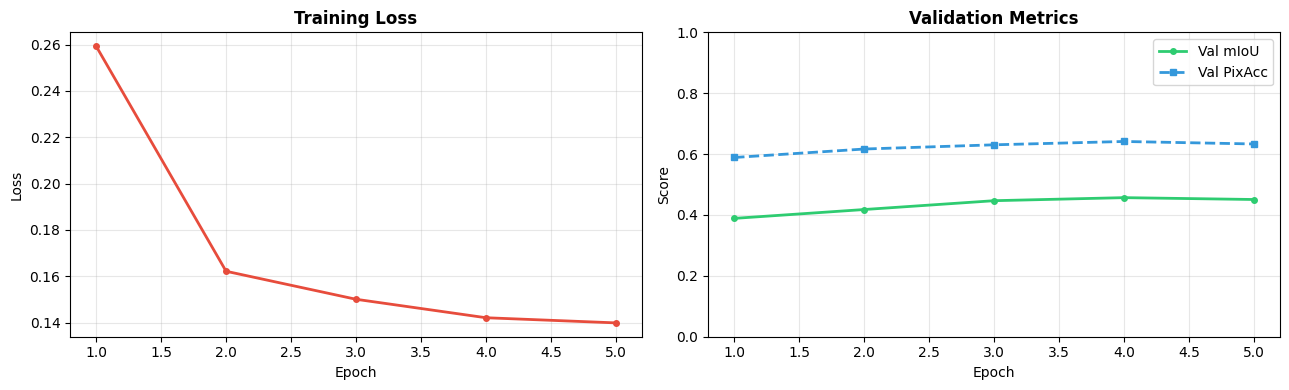

In [ ]:
epochs_x = list(range(1, cfg_run.epochs + 1))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(epochs_x, run_result['history']['train_loss'],
        color='#e74c3c', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training Loss', fontweight='bold')
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epochs_x, run_result['history']['val_miou'],
        color='#2ecc71', linewidth=2, marker='o', markersize=4, label='Val mIoU')
ax.plot(epochs_x, run_result['history']['val_acc'],
        color='#3498db', linewidth=2, marker='s', markersize=4,
        linestyle='--', label='Val PixAcc')
ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
ax.set_title('Validation Metrics', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{cfg.output_dir}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Per-Class IoU Heatmap

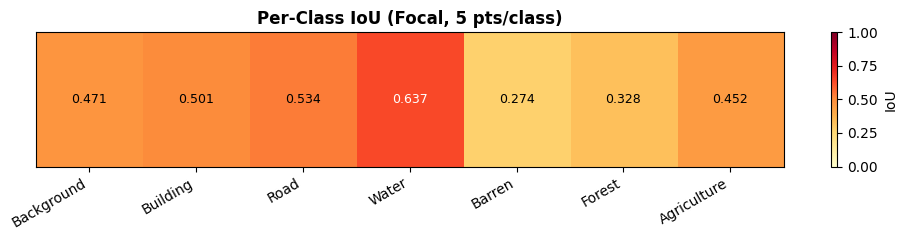

In [ ]:
if run_result['iou_per_class']:
    iou_vals = np.array(run_result['iou_per_class'])
    fig, ax  = plt.subplots(figsize=(10, 2.5))
    im = ax.imshow(iou_vals[np.newaxis, :], cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(cfg.num_classes))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=10)
    ax.set_yticks([]); ax.set_title('Per-Class IoU (Focal, 5 pts/class)', fontweight='bold')
    plt.colorbar(im, ax=ax, label='IoU')
    for j, iou in enumerate(iou_vals):
        ax.text(j, 0, f'{iou:.3f}', ha='center', va='center', fontsize=9,
                color='black' if iou < 0.6 else 'white')
    plt.tight_layout()
    plt.savefig(f'{cfg.output_dir}/per_class_iou.png', dpi=150, bbox_inches='tight')
    plt.show()


[Train/Urban] Found images at: /kaggle/input/datasets/mohammedjaveed/loveda-dataset/Train/Train/Urban/images_png
[Train/Rural] Found images at: /kaggle/input/datasets/mohammedjaveed/loveda-dataset/Train/Train/Rural/images_png
[Train] Total: 2522 samples from ['Urban', 'Rural']
[Val/Urban] Found images at: /kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Urban/images_png
[Val/Rural] Found images at: /kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/images_png
[Val] Total: 1669 samples from ['Urban', 'Rural']


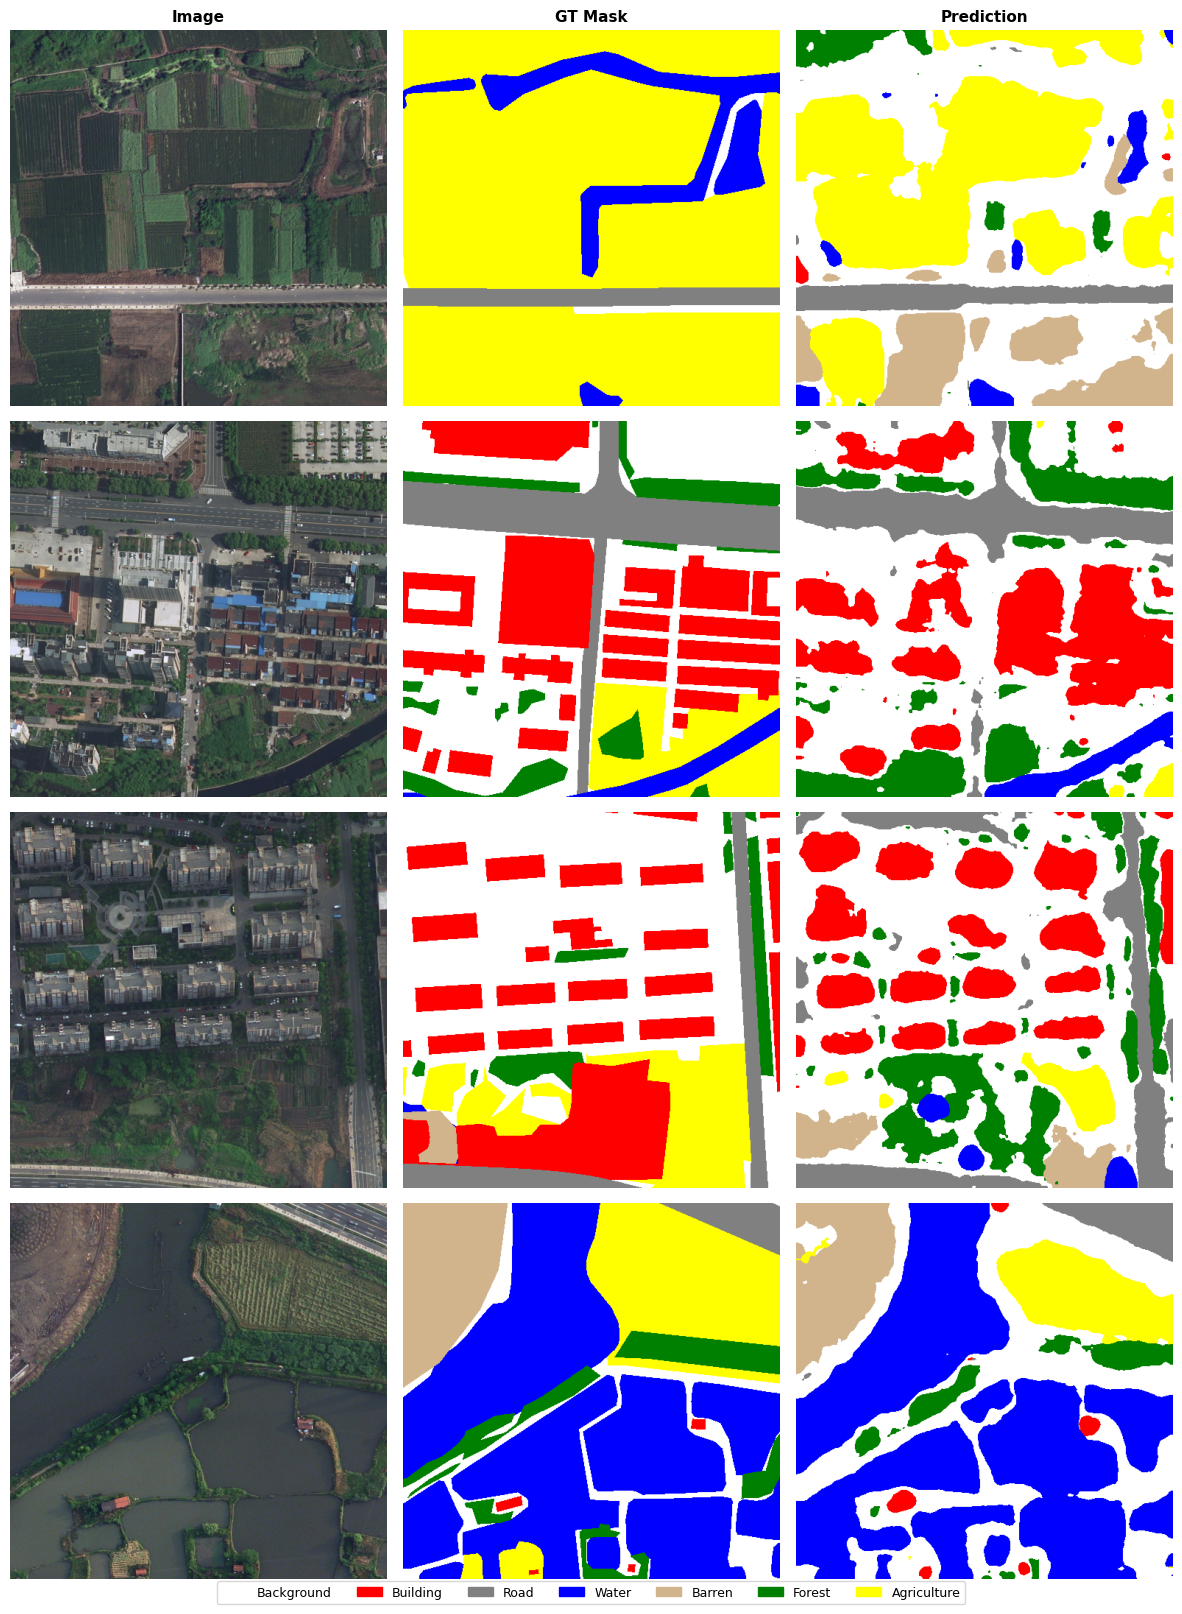

In [ ]:
# Qualitative predictions on 4 val images
_, val_loader_viz = build_dataloaders(cfg_run)

def label_to_rgb(label):
    return CLASS_COLORS[np.clip(label, 0, len(CLASS_COLORS)-1)]

trainer.model.eval()
batch  = next(iter(val_loader_viz))
images = batch['image'][:4].to(DEVICE)
masks  = batch['mask'][:4]
H, W   = images.shape[2], images.shape[3]

with torch.no_grad():
    preds = get_logits(trainer.model, images, (H, W)).argmax(dim=1).cpu()

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for col, t in enumerate(['Image', 'GT Mask', 'Prediction']):
    axes[0, col].set_title(t, fontsize=11, fontweight='bold')

for i in range(4):
    img_np = images[i].cpu().permute(1,2,0).numpy()
    img_np = np.clip(img_np * IMAGENET_STD + IMAGENET_MEAN, 0, 1)
    axes[i,0].imshow(img_np)
    axes[i,1].imshow(label_to_rgb(masks[i].numpy()))
    axes[i,2].imshow(label_to_rgb(preds[i].numpy()))
    for j in range(3): axes[i,j].axis('off')

patches = [mpatches.Patch(color=np.array(c)/255, label=n)
           for c, n in zip(CLASS_COLORS.tolist(), CLASS_NAMES)]
fig.legend(handles=patches, loc='lower center', ncol=7,
           fontsize=9, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout()
plt.savefig(f'{cfg.output_dir}/qualitative.png', dpi=120, bbox_inches='tight')
plt.show()


<!-- removed cell 25 -->

<!-- removed cell 26 -->

<!-- removed cell 27 -->

<!-- removed cell 28 -->

<!-- removed cell 29 -->

<!-- removed cell 30 -->